# Overview
This Jupyter notebook implements an interactive plot of the Multivariate Gaussian for the case here $D = 2$.
Read through the code, adjust the parameters of the function, and then answer the conceptual questions at the end of the notebook. 

## How to use this Notebook:
The script that implements the bivariate Gaussian distribution contains useful reference material for implementing the multivariate gaussian and plotting. Make sure that you take time to read through and understand each part of the program!

## The Multivariate Gaussian
### Definition
In the video you just watched, Peter presented the multivariate Gaussian distribution:
$\mathcal{N}(\vec{x}|(\vec{\mu},\vec{\Sigma})) = (2\pi)^{\frac{-D}{2}} |\vec{\Sigma}|^{\frac{-1}{2}} exp\left\{-\frac{1}{2}(\vec{x}-\vec{\mu})^T\vec{\Sigma}^{-1}(\vec{x}-\vec{\mu})\right\}$.

The quadratic form in the exponential term can be defined in terms of the Mahalanobis distance, $\Delta$, squared. $\Delta^2 = (\vec{x}-\vec{\mu})^T\vec{\Sigma}^{-1}(\vec{x}-\vec{\mu})$
$\mathcal{N}(\vec{x}|(\vec{\mu},\vec{\Sigma})) = (2\pi)^{\frac{-D}{2}} |\vec{\Sigma}|^{\frac{-1}{2}} exp\left\{-\frac{1}{2}\Delta^2\right\}$.

### Plotting Space
Because $D = 2$, there are two random variables: $x_1$ and $x_2$. This demo evaluates the multivariate Gaussian distribution over the meshgrid of these two random variables. 

### The Mean
The user gets to indpendently set the means of the Gaussian distribution of each dimension, $D$. These are captured by the input sliders, $\mu_1$ and $\mu_2$. 


### The Covariance Matrix
The user also gets to specify the terms of a covariance matrix, given by three adjustable sliders:

$\sigma_1$, the standard deviation of the first dimension.

$\sigma_2$, the standard deviation of the second dimension.

$\rho$, a term that controls the degree of covariance between the terms.

Together, the covariance matrix becomes:

$\vec{\Sigma} = 
\begin{pmatrix}
  \sigma_{x1}^2 & \rho\sigma_{x1}\sigma_{x2}\\ 
  \rho\sigma_{x1}\sigma_{x2} & \sigma_{x2}^2
\end{pmatrix}$.

The function will display the computed covariance matrix for your reference.

## Import Key Libraries
We will need the [NumPy linear algebra toolkit](https://numpy.org/doc/stable/reference/routines.linalg.html) to get some helpful functions for implemeting linear algebra in Python. 

In particular, 

1. We will want to take the determinant. [The documentation for the `.det()` function can be found here](https://numpy.org/doc/stable/reference/generated/numpy.linalg.det.html#numpy.linalg.det).

2. We will want to take the invert matrices. [The documentation for the `.inv()` function can be found here](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html#numpy.linalg.inv)

Lastly, we will see the `@` symbol in this script, which is equivalent to the NumPy function `matmul()`. This offers a more concise and readable way to structure our code. If you are interested learning more about this, [you can read more here](https://peps.python.org/pep-0465/).

[The `matmul()` documentation can be found here](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html).

In [1]:
%matplotlib widget
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
import ipywidgets as widgets

## Plot the Multivariate Gaussian Distribution:

This simulation will compute 4096 data points


interactive(children=(FloatSlider(value=0.0, description='$\\mu_1$:', max=10.0, min=-10.0), FloatSlider(value=…

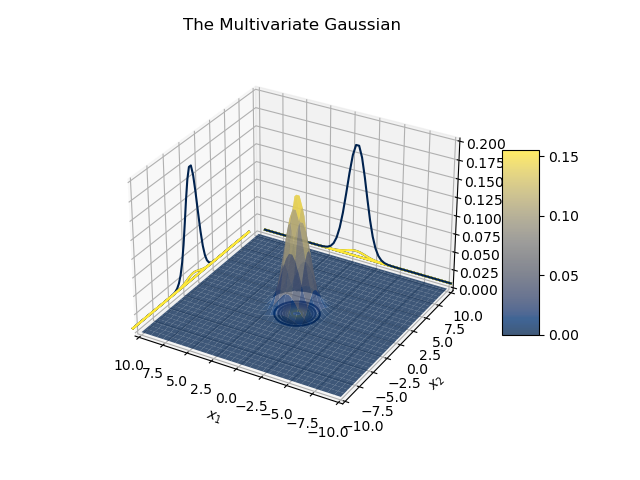

In [2]:
# ==========================================================================
## Generate our plotting space
# ==========================================================================
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Specify the number of dimensions:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# In this demo, to make the visualization managable, we will use 2 dimensions.
# This results in the bivaraiate Gaussian distribution.
D = 2

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Specify the length of a row/column in our grid:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# N_x is the length of the x_vector
# We will use it to create a N_x by N_x grid that will define the points of our plot
# This yields (N_x)^2 calculations of the Multivariate Gaussian
N_x = 64

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Display Size of Requested Data:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# How many data points we want to use in an N_x x N_x
# The number of data points is related to the speed of graphical update
# So we want to be cognizant of how much data we are requesting.
N_data_points = N_x**2
print("This simulation will compute {} data points".format(N_data_points))

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Define a row or column of the grid:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Specify the min and max values:
x_min = -10
x_max = 10
## Create the vector:
x = np.linspace(x_min,x_max,N_x)

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Create the grid for plotting:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Like we saw in the Dirichlet distribution visualization lab and Bayesian 
# update lab, we need a mesh grid that covers every coordinate pair of our
# space for plotting.
x1,x2 = np.meshgrid(x,x)

# ==========================================================================
## Compute the bivariate Gaussian distribution:
# ==========================================================================
# Defining the distribution as a function lets us call it easily in later
# functions.
def multivariate_gaussian_dist(x1,x2,mu,covariance_matrix,N_x):    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Compute the Gaussian:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Rather than trying to compute this in a single line, we will break 
    ## this up into a few component parts.
    ## Start by resetting the matrix that holds this iteration of the distribution:
    distribution = np.zeros((N_x,N_x))
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Compute the Gaussian:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Now index over all values of the meshgrid, considering the value of the 
    ## distribution at each point: 
    for j in range(N_x):
        for k in range(N_x):
            
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## Compute the Gaussian:
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## taking coordinate pairs from x1 and x2 to match the shape of our mu vector:
            ## If we don't reshape the result, it will take the form (2,), which will
            ## Cause a problem for our linear algebra in a moment.
            x_slice = np.array([x1[j,k],x2[j,k]]).reshape(2,1)
            
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## The find the difference between x and mu:
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            sample_mean_difference = x_slice-mu
            
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## Compute the squared Mahalanobis distance:
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## The @ symbol means the same thing as the .matmul function.
            ## I made the mistake of not inverting the covariance matrix here when this 
            ## script was intially developed. This, unsurprisingly, gives inverted
            ## behavior in the graph--increasing the variance made the plot narrower!
            ## Oops. It is easy to make mistakes like this--be wary and always check
            ## to make sure that the behavior you are observing matches what you
            ## would expect. None of us are immune to making mistakes and we should be
            ## always on the look out for errors! The inverse of the covariance matrix
            ## is the precision matrix. We will often work with both the precision
            ## matrix and the covariance matrix in our models going forward in this
            ## class. Mixing these up is a particularly nerfarious bug in code, because
            ## it won't throw an error. Both are 2x2 matricies, so a mahalanobis distance
            ## squared will be computer, it will just be wrong. 
            mahalanobis_distance_squared = sample_mean_difference.T@la.inv(covariance_matrix)@sample_mean_difference
            
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## Compute the exponential term:
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            gaussian_exponent = np.exp((-1/2)*mahalanobis_distance_squared)
            
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## Compute the Normalization term:
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## This is where the second NumPy linear algebra function will be useful:
            ## We compute the coefficient that helps normalize the distribution.
            normalization_term = (2*np.pi)**(-D/2)*(la.det(covariance_matrix)**(-1/2))
            
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            ## Compute the Gaussian:
            # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
            distribution[j,k] = np.squeeze(normalization_term*gaussian_exponent)
    
    return distribution

# ==========================================================================
## Create the figure:
# ==========================================================================
# Creating the figure ahead of time will make the interactive figure's response
# much smoother. We don't want to recreate the figure each time!
# We just want to update the data in the figure we already have.
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# ==========================================================================
## Create the sliders for input parameters:
# ==========================================================================
# We create two sliders that result in a float and specify the default value,
# The min and max of the linear slider, and the 
@widgets.interact(
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Sliders for the means:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    mu1=widgets.FloatSlider(
        value=0, min=x_min, max=x_max, step=.1,
        description=r'$\mu_1$:'),
    
    mu2=widgets.FloatSlider(
        value=0, min=x_min, max=x_max, step=.1,
        description=r'$\mu_2$:'),
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Sliders for the covariance matrix:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    std_dev_x1=widgets.FloatSlider(
        value=1, min=0.1, max=5, step=.1,
        description=r'$\sigma_{x_1}$:'),
    
    std_dev_x2=widgets.FloatSlider(
        value=1, min=0.1, max=5, step=.1,
        description=r'$\sigma_{x_2}$:'),

    rho=widgets.FloatSlider(
        value=0, min=-0.9, max=0.9, step=.1,
        description=r'$\rho$:'),

    ## +++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Set the type of plot:
    ## +++++++++++++++++++++++++++++++++++++++++++++++++++++++
    view = widgets.Dropdown(
    options=['Surface','Scatter'], value = 'Surface',
    description=r'View')) 

# ==========================================================================
## Update the Plot when the type, mu, or the covariance matrix change:
# ==========================================================================
def update(mu1=0, mu2=0, std_dev_x1=1, std_dev_x2=1, rho=0, view='Surface'):
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Generate our input matricies from our slider data:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Create a 2x1 matrix for our means:
    mu = np.array([mu1,mu2]).reshape(2,1)
    
    ## Generate the covariance matrix:
    covariance_matrix = np.array([[std_dev_x1**2,rho*std_dev_x1*std_dev_x2],[rho*std_dev_x1*std_dev_x2,std_dev_x2**2]])
    
    ## Compute the distribution:
    distribution = multivariate_gaussian_dist(x1,x2,mu,covariance_matrix,N_x)
    
    ## Find the maximum value for axis scaling:
    max_value = np.max(distribution)     
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Clear the figure and reset to a 3d plot:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## If we don't do this, the colorbar will keep reprinting itself without
    ## removing past copies until it blots out the sun.
    plt.clf()
    ax = plt.axes(projection="3d")
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Select the view:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    if view == 'Surface':
        surf = ax.plot_surface(x1, x2, distribution, lw=0, alpha=0.75, cmap = 'cividis', vmin=0, vmax=max_value)
        fig.colorbar(surf, shrink=0.5, aspect=5)
    else:
        surf = ax.scatter(x1, x2, distribution, lw=0, alpha=0.75)
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Add contour plots that project onto the axes:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax.contour(x1, x2, distribution, zdir='z', offset=-0.005, cmap='cividis', vmin=0, vmax=max_value)
    ax.contour(x1, x2, distribution, zdir='x', offset=x_max+1, cmap='cividis', vmin=0, vmax=max_value)
    ax.contour(x1, x2, distribution, zdir='y', offset=x_max+1, cmap='cividis', vmin=0, vmax=max_value)
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Set the axis limits:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Align the x and y axes so it's easy to visualize and verify the covariance
    ax.set_ylim(x_min,x_max)
    ax.set_xlim(x_max,x_min)
    
    ## Set a few regions of fixed z axes so we can see how the plot updates
    ## within some bands as we adjust the sliders:
    if max_value > 1:
        ax.set_zlim(0,37)
    elif max_value > 0.2:
        ax.set_zlim(0,1.5)
    elif 0.2 >= max_value > 0.05: 
        ax.set_zlim(0,0.2)
    elif 0.05 >= max_value > 0.01:
        ax.set_zlim(0,0.05)
    else:
        ax.set_zlim(0,0.01)
        
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Set the axes titles:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax.set_title(r'The Multivariate Gaussian', pad=20)
    ax.set_xlabel(r'$x_{1}$')
    ax.set_ylabel(r'$x_{2}$')
    ax.zaxis.set_rotate_label(False) 
    ax.set_zlabel(r'$\mathcal{N}$',rotation=0)
    plt.draw()
    
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ## Print the covariance matrix for the user's reference:
    # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++    
    print("The covariance matrix is:\n{}".format(covariance_matrix))
    print("The maximum value of the distribution is: {}.".format(np.round(max_value,2)))
    return

## Reflection Questions
Please answer the following questions in Part 2 of this assignment.

### Question 1:
What does adjusting the parameters $\mu_k$ do? Does varying $\vec{\mu}$ influence the maximum value of the distribution? Please elaborate.

Changing the mean values, $\mu_1$ and $\mu_2$, moves the center of the bivariate Gaussian distribution along the two coordinate axes. It changes where the distribution is located, but it does not change the maximum height of the peak.

This is because the mean vector, $\vec{\mu}$, only controls the position of the distribution. The height of the probability surface is controlled by the covariance matrix, $\mathbf{\Sigma}$, since the covariance determines how spread out and shaped the distribution is.

### Question 2:
What does increasing $\sigma_{x1}$ do to the distribution? What does increasing $\sigma_{x2}$ do to the distribution? What happens when $\sigma_{x1} = \sigma_{x2}$?

Increasing $\sigma_{x1}$ spreads the distribution out more in the $x_1$ direction. This makes the surface wider horizontally and lowers the peak because the probability is spread over a larger area.

Increasing $\sigma_{x2}$ does the same thing in the $x_2$ direction. It spreads the distribution vertically and also reduces the peak height.

When $\sigma_{x1} = \sigma_{x2}$, the distribution has the same amount of spread in both directions. If $\rho = 0$, the contour lines are circular because the two variables are not correlated. If $\rho$ is not zero, the contours stretch diagonally, showing that the variables are related even though both directions have the same standard deviation.

### Question 3:
What does the parameter $\rho$ do? What happens when $\rho$ is a positive value? What happens when $\rho$ is a negative value?

The parameter $\rho$ is the correlation coefficient. It controls how strongly the two variables are related and which diagonal direction the distribution stretches.

When $\rho$ is positive, the contours tilt upward from the lower-left to the upper-right. This means that as $x_1$ increases, $x_2$ also tends to increase.

When $\rho$ is negative, the contours tilt downward from the upper-left to the lower-right. This means that as one variable increases, the other tends to decrease.

### Question 4:
What are the dimensions of the square of the Mahalanobis distance, $\Delta^2$? Set the view to `Scatter` and observe the distribution. How many data points are there for a particular coordinate `[x1,x2]`?

The squared Mahalanobis distance, $\Delta^2$, gives one single number. This makes sense because the calculation multiplies a $1 \times 2$ row vector, a $2 \times 2$ matrix, and a $2 \times 1$ column vector. The final result is a $1 \times 1$ scalar value.

When the plot is changed to the scatter plot view, each point on the meshgrid has its own probability density value. In other words, every unique coordinate pair, $[x_1, x_2]$, has one calculated density value assigned to it.

### Question 5:
What combination of inputs possible on the sliders, $\mu_{x1}$, $\mu_{x2}$, $\sigma_{x1}$, $\sigma_{x2}$, and $\rho$, results in the greatest peak value of the distribution? Does the sign of $\rho$ matter in this question?

The greatest peak value happens when both standard deviations, σx1 and σx2, are set to their smallest possible slider values. In this notebook, that means σx1 = 0.1 and σx2 = 0.1. Smaller standard deviations make the distribution narrower, so the probability mass is concentrated into a smaller area and the peak becomes taller.

The mean values, μx1 and μx2, do not control the peak height. They mainly move the location of the distribution across the x1 and x2 axes.

The correlation value, ρ, also affects the peak height. The sign of ρ does not matter because ρ appears as ρ² in the analytic model. A positive and negative value with the same magnitude will produce the same peak height. What matters is the magnitude of ρ. Since the slider allows ρ to range from -0.9 to 0.9, the greatest peak occurs when ρ is either 0.9 or -0.9.

This matches the analytic model because the denominator includes √(1 - ρ²). As |ρ| gets larger, that denominator becomes smaller, which increases the peak value.

### Question 6: 
What is the peak value under these conditions?

The peak height can be calculated with the formula:

$$
\frac{1}{2\pi\sigma_{x1}\sigma_{x2}\sqrt{1-\rho^2}}
$$

To find the maximum value in my notebook, I would use the smallest allowed values for $\sigma_{x1}$ and $\sigma_{x2}$, and the largest allowed value of $|\rho|$ without making $\rho$ equal to $1$ or $-1$.

For example, if the minimum slider values are $\sigma_{x1} = 0.5$ and $\sigma_{x2} = 0.5$, and if $\rho = 0$, then the peak value is:

$$
\frac{1}{2\pi(0.5)(0.5)\sqrt{1-0^2}} = 0.637
$$

So with those specific settings, the peak height is approximately $0.637$. However, this is only the value when $\rho = 0$. If the slider allows $\rho$ to move closer to $1$ or $-1$, the peak height would be larger because the $\sqrt{1-\rho^2}$ term in the denominator becomes smaller.

### Question 7:
Why does increasing the magnitude of $\rho$ increase the magnitude of the plot? Why can't $\rho = 1$?

Increasing the size of $\rho$ makes the distribution stretch into a narrower diagonal ridge. As that ridge gets narrower, the peak gets taller.

This happens because the determinant of the covariance matrix is:

$$
|\mathbf{\Sigma}| = \sigma_{x1}^2\sigma_{x2}^2(1-\rho^2)
$$

As $|\rho|$ gets closer to $1$, the term $(1-\rho^2)$ gets closer to zero. That makes the determinant smaller. Since the Gaussian formula divides by $\sqrt{|\mathbf{\Sigma}|}$, a smaller determinant makes the peak height increase.

The value of $\rho$ cannot be exactly $1$ or $-1$ because then the determinant becomes zero. At that point, the covariance matrix is singular, so $\mathbf{\Sigma}^{-1}$ cannot be calculated. In practical terms, the 2D distribution collapses into a 1D line, and the bivariate Gaussian formula no longer works normally.

### Question 8:
Continue adjusting parameters until you feel like you have a good understanding of how this distribution behaves. Please take a moment to reflect on what you observed here. Was there anything that surprised you? Looking at the code, does this program square with your conceptual understanding of the multivariate Gaussian distribution?

Working through the parameters hands-on matches what I understand conceptually about the multivariate Gaussian distribution. It helps to actually see how changing the covariance and correlation values changes the shape of the 3D probability surface.

I also found it useful to see how the code uses the `numpy.linalg` package to calculate matrix determinants and inverses. That made the linear algebra behind the distribution feel more concrete instead of just being formulas on paper.